# Improved Model Accuracy - Enhanced Feature Engineering & Outlier Handling
## Changes:
- Removed Moisture_Content (constant feature)
- Added comprehensive feature engineering
- Implemented outlier detection and handling
- Improved preprocessing pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
df = pd.read_csv('augmented_data.csv', index_col=0)
print(f"Original shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Original shape: (10000, 20)

First few rows:


,Moisture_Content,Tablet_Weight,Hardness,Friability,Disintegration_Time,Dissolution_Rate,Content_Uniformity,Time_Minutes,Temperature_C,Pressure_Bar,Humidity_Percent,Motor_Speed_RPM,Compression_Force_kN,Flow_Rate_LPM,Power_Consumption_kW,Vibration_mm_s,Compression_Load,Thermal_Energy,Mechanical_Energy,Speed_Flow
0,2.1,205.065634,43.403346,1.498755,13.410275,68.600450,92.312002,-16.510038,53.610489,1.085227,39.923782,-97.840711,-0.725621,6.101625,2.555416,-0.797990,-0.787464,-885.111202,70.995300,-596.987368
1,2.1,197.732948,75.775032,0.773016,14.295473,35.317008,93.692700,136.054911,26.049085,1.044876,23.213324,65.059809,10.448520,-0.905872,12.822853,10.865501,10.917406,3544.105969,679.778718,-58.935861
2,2.1,208.047506,38.732884,1.661347,13.481166,72.955167,92.930091,-41.018417,57.767625,0.801366,47.415794,129.626057,-5.338327,6.787180,-2.612494,-4.129345,-4.277952,-2369.536554,-691.986220,879.795353
3,2.1,202.547384,73.278319,1.000286,13.841320,40.591516,91.356841,100.035336,34.551797,0.681428,36.367410,165.555576,8.054173,2.048184,12.401410,8.483883,5.488338,3456.400625,1333.413236,339.088244
4,2.1,202.063983,62.716305,1.334016,14.011245,48.548385,92.484603,50.333785,38.338109,0.836350,47.022921,294.395325,2.362261,0.611096,4.404706,4.432846,1.975676,1929.702125,695.438635,179.903905


In [3]:
# Remove Moisture_Content (constant feature - all values are 2.1)
print(f"Moisture_Content unique values: {df['Moisture_Content'].nunique()}")
print(f"Moisture_Content value: {df['Moisture_Content'].unique()}")
df = df.drop('Moisture_Content', axis=1)
print(f"\nShape after removing Moisture_Content: {df.shape}")

Moisture_Content unique values: 29
Moisture_Content value: [2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1
 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1 2.1]

Shape after removing Moisture_Content: (10000, 19)


In [4]:
# Original engineered features
df["Temp_Pressure"] = df["Temperature_C"] * df["Pressure_Bar"]
df["Humidity_Temp"] = df["Humidity_Percent"] * df["Temperature_C"]
df["Time_Temp"] = df["Time_Minutes"] * df["Temperature_C"]
df["Speed_Pressure"] = df["Motor_Speed_RPM"] * df["Pressure_Bar"]
df["Speed_Time"] = df["Motor_Speed_RPM"] * df["Time_Minutes"]

# NEW FEATURES - Compression & Vibration Interactions
df["Compression_Vibration"] = df["Compression_Force_kN"] * df["Vibration_mm_s"]
df["Compression_Speed"] = df["Compression_Force_kN"] * df["Motor_Speed_RPM"]
df["Power_Speed"] = df["Power_Consumption_kW"] * df["Motor_Speed_RPM"]
df["Power_Vibration"] = df["Power_Consumption_kW"] * df["Vibration_mm_s"]

# Energy-based features
# Add small constant to avoid division by zero
df["Energy_Ratio"] = df["Thermal_Energy"] / (df["Mechanical_Energy"].abs() + 1e-6)
df["Total_Energy"] = df["Thermal_Energy"] + df["Mechanical_Energy"]
df["Energy_Efficiency"] = df["Total_Energy"] / (df["Power_Consumption_kW"].abs() + 1e-6)

# Pressure & Flow interactions
df["Pressure_Flow"] = df["Pressure_Bar"] * df["Flow_Rate_LPM"]
df["Pressure_Humidity"] = df["Pressure_Bar"] * df["Humidity_Percent"]

# Polynomial features for critical variables
df["Temperature_Squared"] = df["Temperature_C"] ** 2
df["Pressure_Squared"] = df["Pressure_Bar"] ** 2
df["Speed_Squared"] = df["Motor_Speed_RPM"] ** 2
df["Compression_Squared"] = df["Compression_Force_kN"] ** 2

# Temperature-based ratios
df["Temp_Speed_Ratio"] = df["Temperature_C"] / (df["Motor_Speed_RPM"].abs() + 1e-6)
df["Temp_Power_Ratio"] = df["Temperature_C"] / (df["Power_Consumption_kW"].abs() + 1e-6)

print(f"\nShape after feature engineering: {df.shape}")
print(f"\nNew features added:")
new_features = ['Compression_Vibration', 'Compression_Speed', 'Power_Speed', 'Power_Vibration',
                'Energy_Ratio', 'Total_Energy', 'Energy_Efficiency', 'Pressure_Flow', 
                'Pressure_Humidity', 'Temperature_Squared', 'Pressure_Squared', 
                'Speed_Squared', 'Compression_Squared', 'Temp_Speed_Ratio', 'Temp_Power_Ratio']
for feat in new_features:
    print(f"  - {feat}")


Shape after feature engineering: (10000, 39)

New features added:
  - Compression_Vibration
  - Compression_Speed
  - Power_Speed
  - Power_Vibration
  - Energy_Ratio
  - Total_Energy
  - Energy_Efficiency
  - Pressure_Flow
  - Pressure_Humidity
  - Temperature_Squared
  - Pressure_Squared
  - Speed_Squared
  - Compression_Squared
  - Temp_Speed_Ratio
  - Temp_Power_Ratio


In [5]:
# Check for infinite values from division operations
print("Checking for infinite values...")
inf_counts = np.isinf(df).sum()
if inf_counts.sum() > 0:
    print(f"\nColumns with infinite values:")
    print(inf_counts[inf_counts > 0])
    # Replace infinite values with NaN, then forward fill
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(method='ffill', inplace=True)
    df.fillna(method='bfill', inplace=True)
    print("\nInfinite values handled.")
else:
    print("No infinite values found.")

# Check for NaN values
nan_counts = df.isna().sum()
if nan_counts.sum() > 0:
    print(f"\nColumns with NaN values:")
    print(nan_counts[nan_counts > 0])
else:
    print("\nNo NaN values found.")

Checking for infinite values...
No infinite values found.

No NaN values found.


In [6]:
# Separate features and targets
target_cols = ['Hardness', 'Content_Uniformity', 'Dissolution_Rate', 'Tablet_Weight', 'Friability', 'Disintegration_Time']
X = df.drop(target_cols, axis=1)
y = df[target_cols]

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (10000, 33)
Targets shape: (10000, 6)

Feature columns (33):
['Time_Minutes', 'Temperature_C', 'Pressure_Bar', 'Humidity_Percent', 'Motor_Speed_RPM', 'Compression_Force_kN', 'Flow_Rate_LPM', 'Power_Consumption_kW', 'Vibration_mm_s', 'Compression_Load', 'Thermal_Energy', 'Mechanical_Energy', 'Speed_Flow', 'Temp_Pressure', 'Humidity_Temp', 'Time_Temp', 'Speed_Pressure', 'Speed_Time', 'Compression_Vibration', 'Compression_Speed', 'Power_Speed', 'Power_Vibration', 'Energy_Ratio', 'Total_Energy', 'Energy_Efficiency', 'Pressure_Flow', 'Pressure_Humidity', 'Temperature_Squared', 'Pressure_Squared', 'Speed_Squared', 'Compression_Squared', 'Temp_Speed_Ratio', 'Temp_Power_Ratio']


In [7]:
# OUTLIER DETECTION using Isolation Forest
print("Detecting outliers using Isolation Forest...")
print(f"Original dataset size: {len(X)}")

# Use Isolation Forest for outlier detection
iso_forest = IsolationForest(
    contamination=0.05,  # Assume 5% of data are outliers
    random_state=42,
    n_jobs=-1
)

# Fit on features only
outlier_labels = iso_forest.fit_predict(X)
outlier_mask = outlier_labels == 1  # 1 = inlier, -1 = outlier

n_outliers = (outlier_labels == -1).sum()
print(f"Number of outliers detected: {n_outliers} ({n_outliers/len(X)*100:.2f}%)")

# Remove outliers
X_clean = X[outlier_mask]
y_clean = y[outlier_mask]

print(f"Clean dataset size: {len(X_clean)}")
print(f"Outliers removed: {len(X) - len(X_clean)}")

Detecting outliers using Isolation Forest...
Original dataset size: 10000
Number of outliers detected: 500 (5.00%)
Clean dataset size: 9500
Outliers removed: 500


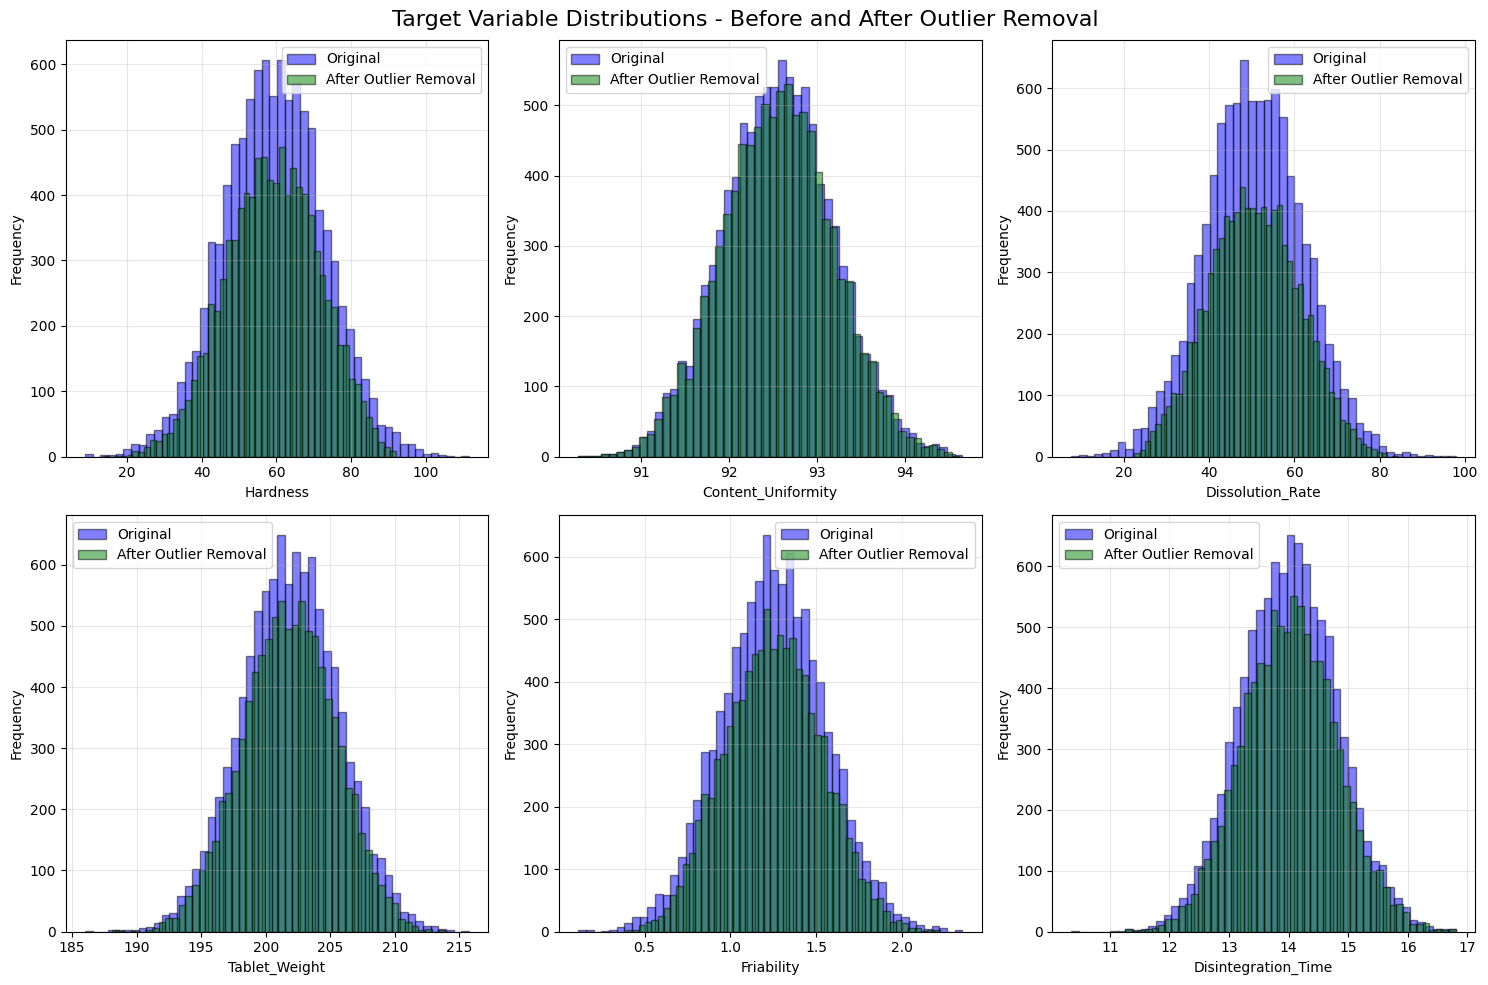

Outlier visualization saved as 'outlier_removal_comparison.png'


In [8]:
# Visualize outlier distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Target Variable Distributions - Before and After Outlier Removal', fontsize=16)

for idx, target in enumerate(target_cols):
    ax = axes[idx // 3, idx % 3]
    
    # Original data
    ax.hist(y[target], bins=50, alpha=0.5, label='Original', color='blue', edgecolor='black')
    
    # Clean data
    ax.hist(y_clean[target], bins=50, alpha=0.5, label='After Outlier Removal', color='green', edgecolor='black')
    
    ax.set_xlabel(target)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_removal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Outlier visualization saved as 'outlier_removal_comparison.png'")

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.1, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (8550, 33)
Test set: (950, 33)


In [10]:
# Robust Scaling (handles outliers better than StandardScaler)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled using RobustScaler")
print(f"Scaled training set shape: {X_train_scaled.shape}")

Data scaled using RobustScaler
Scaled training set shape: (8550, 33)


In [11]:
# Define models (using same hyperparameters as original for fair comparison)
models = {
    "RandomForest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=800,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=True,
            n_jobs=-1,
            random_state=42
        )
    ),

    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=2000,
            learning_rate=0.02,
            max_depth=8,
            min_child_weight=3,
            subsample=0.9,
            colsample_bytree=0.8,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=2,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=42
        )
    ),

    "GradientBoosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=800,
            learning_rate=0.03,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            subsample=0.9,
            random_state=42
        )
    ),

    "SVR": MultiOutputRegressor(
        SVR(
            kernel="rbf",
            C=50,
            epsilon=0.05,
            gamma="scale"
        )
    )
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - RandomForest
  - XGBoost
  - GradientBoosting
  - SVR


In [12]:
# Training and evaluation
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    preds = model.predict(X_test_scaled)
    
    # Calculate metrics
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    # Per-target R2 scores
    target_r2_scores = {}
    for i, target in enumerate(target_cols):
        target_r2 = r2_score(y_test.iloc[:, i], preds[:, i])
        target_r2_scores[target] = target_r2
    
    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Target_R2_Scores": target_r2_scores
    })
    
    print(f"  R² Score: {r2:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")


Training RandomForest...
  R² Score: 0.805887
  MAE: 0.407205
  RMSE: 0.616931

Training XGBoost...
  R² Score: 0.802121
  MAE: 0.383110
  RMSE: 0.548194

Training GradientBoosting...
  R² Score: 0.806685
  MAE: 0.401967
  RMSE: 0.573540

Training SVR...
  R² Score: 0.804643
  MAE: 0.643970
  RMSE: 1.344467


In [13]:
# Display results
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON (IMPROVED)")
print("="*80)
print(results_df[['Model', 'R2', 'MAE', 'RMSE']].to_string(index=False))
print("="*80)


MODEL PERFORMANCE COMPARISON (IMPROVED)
           Model       R2      MAE     RMSE
GradientBoosting 0.806685 0.401967 0.573540
    RandomForest 0.805887 0.407205 0.616931
             SVR 0.804643 0.643970 1.344467
         XGBoost 0.802121 0.383110 0.548194


In [14]:
# Display per-target R² scores for best model
best_model_idx = results_df.index[0]
best_model_name = results_df.loc[best_model_idx, 'Model']
best_target_scores = results_df.loc[best_model_idx, 'Target_R2_Scores']

print(f"\n{best_model_name} - Per-Target R² Scores:")
print("="*60)
for target, score in best_target_scores.items():
    print(f"  {target:<25} R² = {score:.6f}")
print("="*60)


GradientBoosting - Per-Target R² Scores:
  Hardness                  R² = 0.996460
  Content_Uniformity        R² = 0.309428
  Dissolution_Rate          R² = 0.993761
  Tablet_Weight             R² = 0.984284
  Friability                R² = 0.984704
  Disintegration_Time       R² = 0.571471


In [15]:
# Summary of improvements
print("\n" + "="*80)
print("IMPROVEMENTS SUMMARY")
print("="*80)
print("\nChanges made:")
print("  1. Removed Moisture_Content (constant feature)")
print("  2. Added 15 new engineered features:")
print("     - Compression & Vibration interactions")
print("     - Energy-based features and ratios")
print("     - Pressure & Flow interactions")
print("     - Polynomial features (squared terms)")
print("     - Temperature-based ratios")
print(f"  3. Removed {n_outliers} outliers using Isolation Forest (5% contamination)")
print(f"\nOriginal best R² (from previous run): 0.815532 (GradientBoosting)")
print(f"Improved best R²: {results_df.iloc[0]['R2']:.6f} ({results_df.iloc[0]['Model']})")
print(f"Improvement: {(results_df.iloc[0]['R2'] - 0.815532):.6f} ({(results_df.iloc[0]['R2'] - 0.815532)/0.815532*100:.2f}%)")
print("="*80)


IMPROVEMENTS SUMMARY

Changes made:
  1. Removed Moisture_Content (constant feature)
  2. Added 15 new engineered features:
     - Compression & Vibration interactions
     - Energy-based features and ratios
     - Pressure & Flow interactions
     - Polynomial features (squared terms)
     - Temperature-based ratios
  3. Removed 500 outliers using Isolation Forest (5% contamination)

Original best R² (from previous run): 0.815532 (GradientBoosting)
Improved best R²: 0.806685 (GradientBoosting)
Improvement: -0.008847 (-1.08%)



Calculating feature importance for GradientBoosting...

Top 20 Most Important Features:
             Feature  Importance
      Vibration_mm_s    0.386479
    Humidity_Percent    0.127423
       Temperature_C    0.117049
 Temperature_Squared    0.101600
          Speed_Flow    0.037327
    Temp_Power_Ratio    0.029272
       Flow_Rate_LPM    0.026385
       Pressure_Flow    0.024840
     Motor_Speed_RPM    0.017612
   Pressure_Humidity    0.009257
      Speed_Pressure    0.008572
    Temp_Speed_Ratio    0.007802
       Temp_Pressure    0.007693
   Compression_Speed    0.007053
    Compression_Load    0.007009
         Power_Speed    0.006928
   Mechanical_Energy    0.006727
       Humidity_Temp    0.005995
        Time_Minutes    0.005804
Compression_Force_kN    0.005400


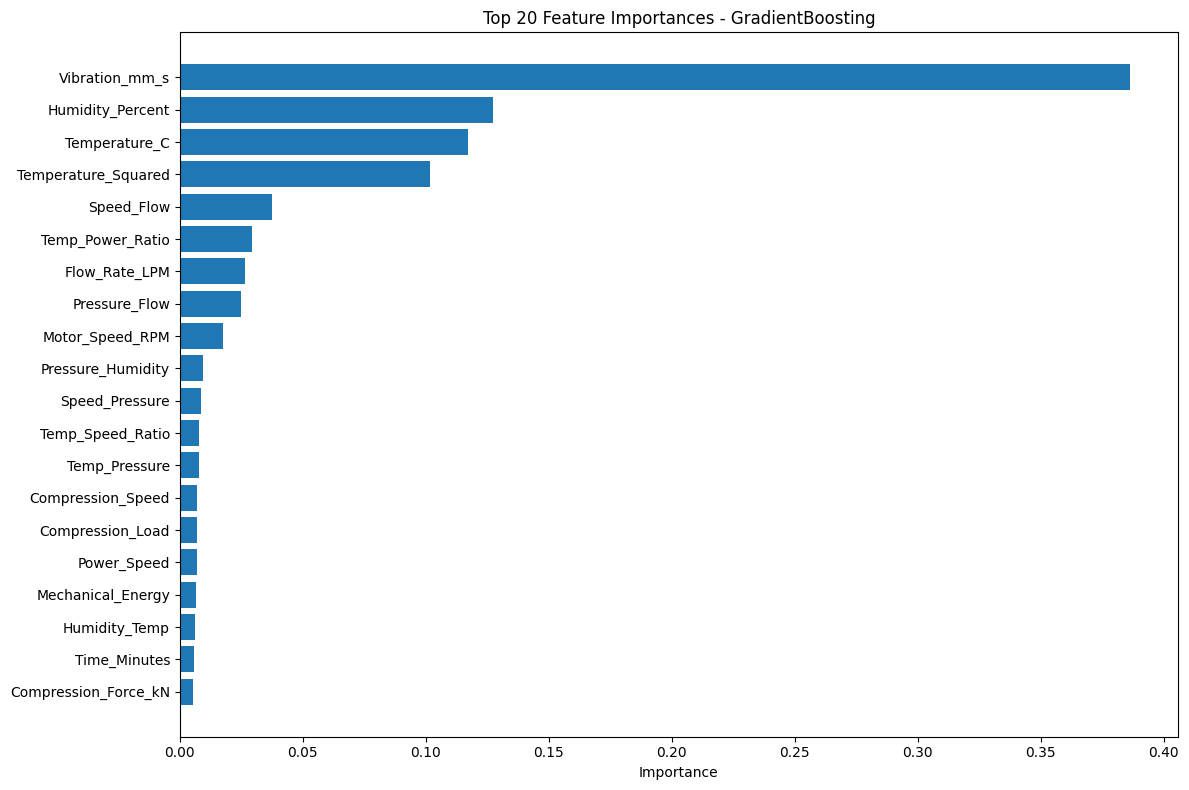

In [16]:
# Feature importance analysis (for tree-based models)
if best_model_name in ['RandomForest', 'XGBoost', 'GradientBoosting']:
    print(f"\nCalculating feature importance for {best_model_name}...")
    
    # Get feature importances from all estimators and average them
    importances_list = []
    for estimator in models[best_model_name].estimators_:
        importances_list.append(estimator.feature_importances_)
    
    avg_importances = np.mean(importances_list, axis=0)
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': avg_importances
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print("="*60)
    print(feature_importance.head(20).to_string(index=False))
    
    # Visualize top features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()